# Convolutional Neural Network



## Import Libraries

In [2]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd()

while not (PROJECT_ROOT / "src").exists() and PROJECT_ROOT != PROJECT_ROOT.parent:
    PROJECT_ROOT = PROJECT_ROOT.parent

sys.path.insert(0, str(PROJECT_ROOT))

print("Project root:", PROJECT_ROOT)

Project root: d:\CompSCI_ITB\Materi\Semester_6\ML\Tubes\Tubes2\Tugas-Besar-ML-2


In [12]:
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models
from sklearn.metrics import classification_report, f1_score, confusion_matrix
from pathlib import Path

from src.common.image_utils import load_image, load_images, list_image_paths_by_class


## Import Dataset

Jumlah train image: 14034
Class names: ['buildings', 'forest', 'glacier', 'mountain', 'sea', 'street']
(150, 150, 3)
0.0 1.0


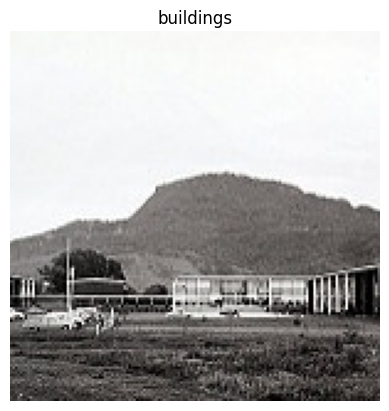

In [5]:
TRAIN_DIR = Path("../../data/raw/intel_image_classification/seg_train")
TEST_DIR = Path("../../data/raw/intel_image_classification/seg_test")

train_paths, train_labels, class_names = list_image_paths_by_class(TRAIN_DIR)

print("Jumlah train image:", len(train_paths))
print("Class names:", class_names)

img = load_image(train_paths[0], target_size=(150, 150))

print(img.shape)
print(img.min(), img.max())

plt.imshow(img)
plt.title(class_names[train_labels[0]])
plt.axis("off")
plt.show()

---
# 1. Exploratory Data Analysis (EDA)



### 1.1 Distribusi Sampel per Kelas



/tmp/ipykernel_18731/1630098141.py:5: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(label_name_map.values())


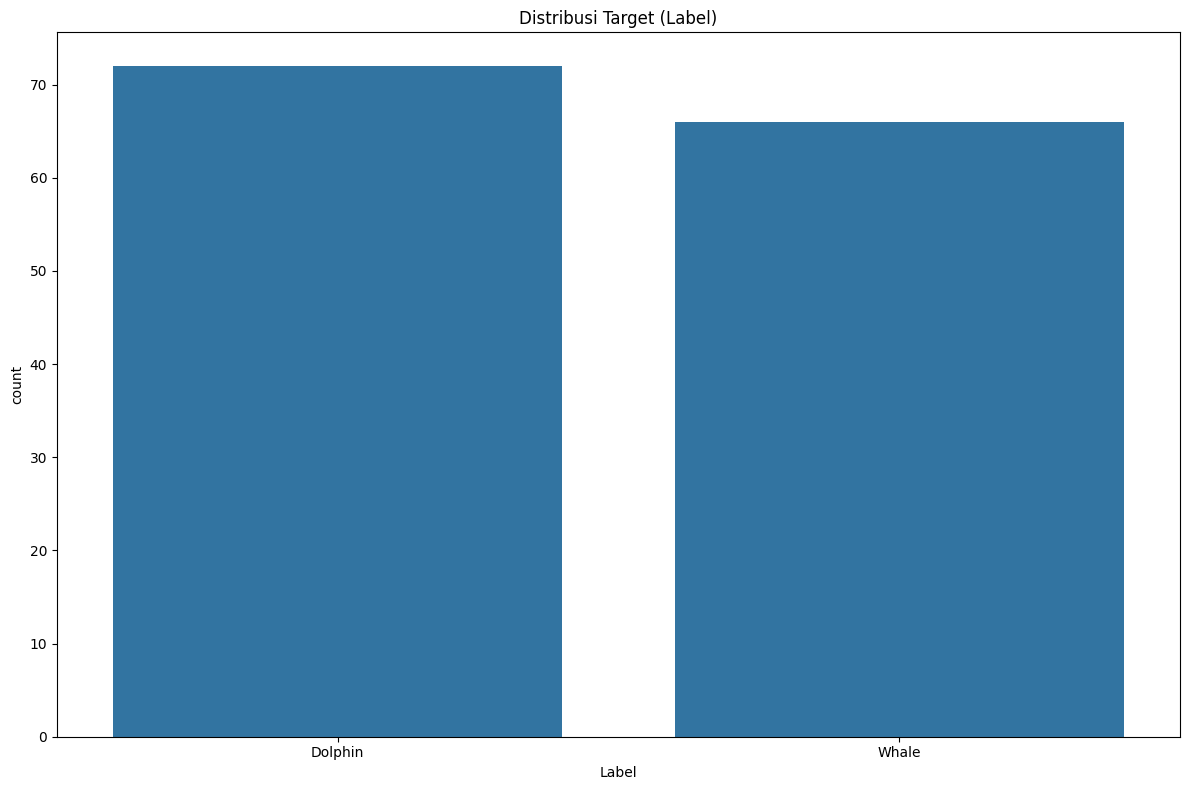

### 1.2 Variasi Dimensi Gambar dan Aspect Ratio



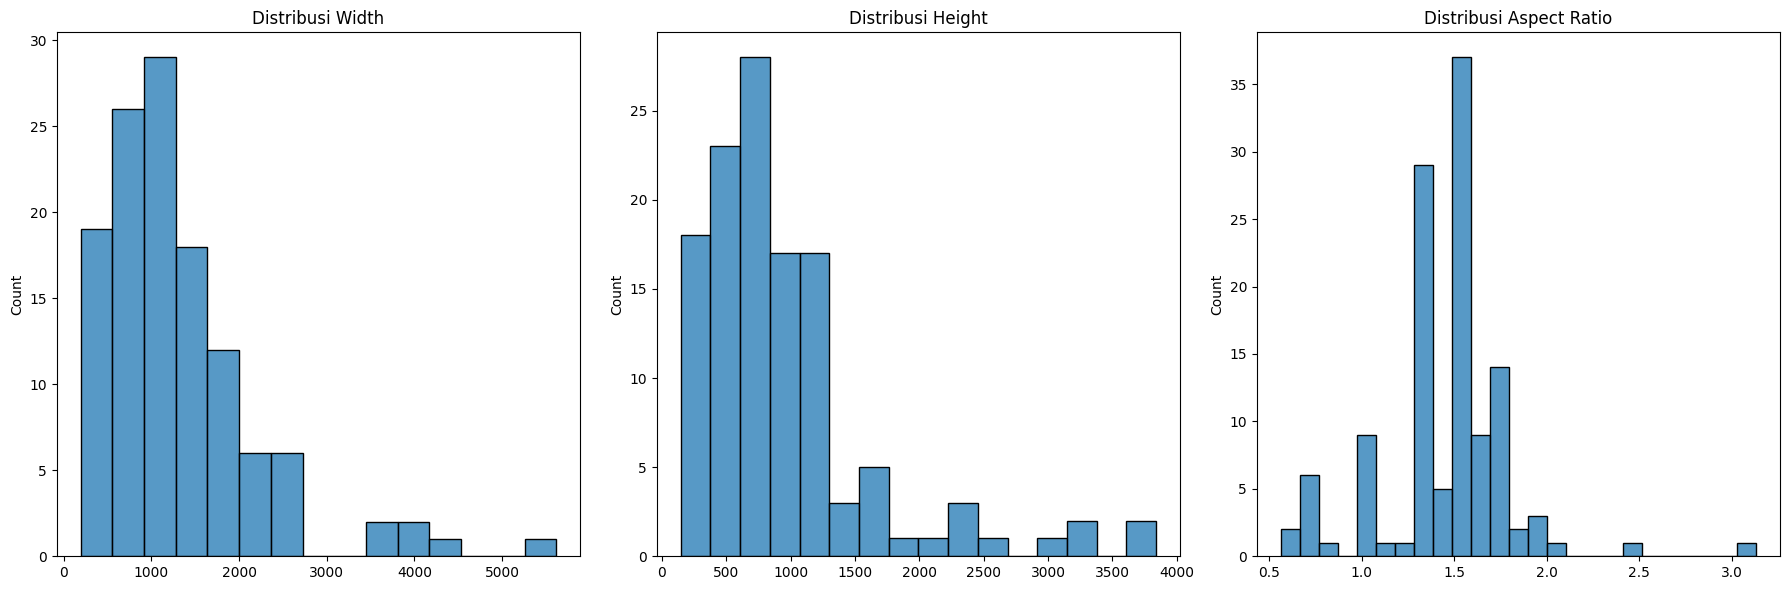

### 1.3 Distribusi Intensitas Nilai Piksel per Kelas



---
# 2. Data Cleaning and Preprocessing



### 2.1 [Wajib] Resizing dan Normalisasi Gambar

Lakukan *resizing* gambar ke dimensi yang konsisten (224×224 untuk AlexNet) dan normalisasi nilai piksel. Justifikasikan pilihan Anda berdasarkan distribusi fitur yang ditemukan di EDA.

### 2.2 [Wajib] Pembagian Dataset

Split the dataset into **training set, validation set, and test set** with reasonable proportions. This is done before augmentation to **avoid data leakage**.

Train: 96
Validation: 21
Test Eval: 21

Train distribution:
Label
0    0.520833
1    0.479167
Name: proportion, dtype: float64

Validation distribution:
Label
0    0.52381
1    0.47619
Name: proportion, dtype: float64

Test Eval distribution:
Label
0    0.52381
1    0.47619
Name: proportion, dtype: float64


### 2.3 [Opsional] Preprocessing Tambahan

Langkah tambahan jika relevan berdasarkan EDA:
- Penanganan outlier jika ditemukan gambar yang rusak, tidak relevan, atau memiliki pencahayaan ekstrem.
- Data augmentation seperti *horizontal flip*, rotasi, atau *brightness adjustment* untuk memperkaya variasi dataset.

*Justification: ...*

### Helper: Custom Dataset Class

### Helper: Training and Evaluation Functions

---
# 3. Modeling and Validation



## 3.1 Baseline CNN Keras



In [8]:
IMG_SIZE = (150, 150)
BATCH_SIZE = 32
NUM_CLASSES = 6


train_ds = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR,
    validation_split=0.2,
    subset="training",
    seed=42,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR,
    validation_split=0.2,
    subset="validation",
    seed=42,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    TEST_DIR,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False,
)

class_names = train_ds.class_names
print(class_names)

Found 14034 files belonging to 6 classes.
Using 11228 files for training.
Found 14034 files belonging to 6 classes.
Using 2806 files for validation.
Found 3000 files belonging to 6 classes.
['buildings', 'forest', 'glacier', 'mountain', 'sea', 'street']


In [9]:
normalization = layers.Rescaling(1./255)

train_ds = train_ds.map(lambda x, y: (normalization(x), y))
val_ds = val_ds.map(lambda x, y: (normalization(x), y))
test_ds = test_ds.map(lambda x, y: (normalization(x), y))

AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.prefetch(AUTOTUNE)
val_ds = val_ds.prefetch(AUTOTUNE)
test_ds = test_ds.prefetch(AUTOTUNE)

In [10]:
def build_baseline_cnn(input_shape=(150, 150, 3), num_classes=6):
    model = models.Sequential([
        layers.Input(shape=input_shape),

        layers.Conv2D(32, kernel_size=(3, 3), padding="same", activation="relu", name="conv1"),
        layers.MaxPooling2D(pool_size=(2, 2), name="pool1"),

        layers.Conv2D(64, kernel_size=(3, 3), padding="same", activation="relu", name="conv2"),
        layers.MaxPooling2D(pool_size=(2, 2), name="pool2"),

        layers.Flatten(name="flatten"),
        layers.Dense(128, activation="relu", name="dense1"),
        layers.Dense(num_classes, activation="softmax", name="output"),
    ])

    model.compile(
        optimizer=tf.keras.optimizers.Adam(),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"],
    )

    return model


baseline_model = build_baseline_cnn(num_classes=NUM_CLASSES)
baseline_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1 (Conv2D)                  │ (None, 150, 150, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool1 (MaxPooling2D)            │ (None, 75, 75, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2 (Conv2D)                  │ (None, 75, 75, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool2 (MaxPooling2D)            │ (None, 37, 37, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 87616)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense1 (Dense)                  │ (None, 128)            │    11,214,976 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,235,142 (42.86 MB)

 Trainable params: 11,235,142 (42.86 MB)

 Non-trainable params: 0 (0.00 B)

In [11]:
history = baseline_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=5,
)

Epoch 1/5
351/351 ━━━━━━━━━━━━━━━━━━━━ 54s 150ms/step - accuracy: 0.6269 - loss: 1.0019 - val_accuracy: 0.7099 - val_loss: 0.7711
Epoch 2/5
351/351 ━━━━━━━━━━━━━━━━━━━━ 47s 135ms/step - accuracy: 0.7718 - loss: 0.6314 - val_accuracy: 0.7523 - val_loss: 0.6826
Epoch 3/5
351/351 ━━━━━━━━━━━━━━━━━━━━ 49s 138ms/step - accuracy: 0.8587 - loss: 0.4034 - val_accuracy: 0.7466 - val_loss: 0.7711
Epoch 4/5
351/351 ━━━━━━━━━━━━━━━━━━━━ 61s 173ms/step - accuracy: 0.9328 - loss: 0.2058 - val_accuracy: 0.7733 - val_loss: 0.8481
Epoch 5/5
351/351 ━━━━━━━━━━━━━━━━━━━━ 47s 133ms/step - accuracy: 0.9604 - loss: 0.1271 - val_accuracy: 0.7666 - val_loss: 0.9590


In [13]:
baseline_model.save("../../models/cnn/baseline_conv2d.keras")
baseline_model.save_weights("../../models/cnn/baseline_conv2d.weights.h5")

In [14]:
y_true = []
y_pred = []

for x_batch, y_batch in test_ds:
    probs = baseline_model.predict(x_batch, verbose=0)
    preds = np.argmax(probs, axis=1)

    y_true.extend(y_batch.numpy())
    y_pred.extend(preds)

macro_f1 = f1_score(y_true, y_pred, average="macro")

print("Macro F1:", macro_f1)
print(classification_report(y_true, y_pred, target_names=class_names))
print(confusion_matrix(y_true, y_pred))

Macro F1: 0.7709234571385548
              precision    recall  f1-score   support

   buildings       0.67      0.79      0.72       437
      forest       0.98      0.82      0.89       474
     glacier       0.75      0.73      0.74       553
    mountain       0.72      0.75      0.74       525
         sea       0.76      0.71      0.74       510
      street       0.77      0.82      0.80       501

    accuracy                           0.77      3000
   macro avg       0.78      0.77      0.77      3000
weighted avg       0.78      0.77      0.77      3000

[[344   0   9  14  10  60]
 [ 40 387   3   5   2  37]
 [ 17   2 401  71  55   7]
 [ 16   1  62 396  43   7]
 [ 24   1  50  60 364  11]
 [ 73   3   7   4   2 412]]


---
## 3.2 -



Epoch [01/10] | Train Loss: 0.0729 | Val Loss: 0.4701 | Train F1: 0.9896 | Val F1: 0.8558 | Train Acc: 0.9896 | Val Acc: 0.8571
Epoch [02/10] | Train Loss: 0.0404 | Val Loss: 0.4546 | Train F1: 1.0000 | Val F1: 0.8558 | Train Acc: 1.0000 | Val Acc: 0.8571
Epoch [03/10] | Train Loss: 0.0245 | Val Loss: 0.4682 | Train F1: 1.0000 | Val F1: 0.9028 | Train Acc: 1.0000 | Val Acc: 0.9048
Epoch [04/10] | Train Loss: 0.0146 | Val Loss: 0.4788 | Train F1: 1.0000 | Val F1: 0.9028 | Train Acc: 1.0000 | Val Acc: 0.9048
Epoch [05/10] | Train Loss: 0.0160 | Val Loss: 0.4695 | Train F1: 1.0000 | Val F1: 0.9028 | Train Acc: 1.0000 | Val Acc: 0.9048
Epoch [06/10] | Train Loss: 0.0244 | Val Loss: 0.4360 | Train F1: 0.9896 | Val F1: 0.8558 | Train Acc: 0.9896 | Val Acc: 0.8571
Epoch [07/10] | Train Loss: 0.0086 | Val Loss: 0.4083 | Train F1: 1.0000 | Val F1: 0.8091 | Train Acc: 1.0000 | Val Acc: 0.8095
Epoch [08/10] | Train Loss: 0.0037 | Val Loss: 0.4400 | Train F1: 1.0000 | Val F1: 0.7619 | Train Acc: 1